# AG News Classification: DistilBERT vs ELECTRA‑small
**Sequence‑based NLP** – fine‑tuning Transformer encoders with Optuna optimisation.


## 1. Install & Imports

We import all necessary libraries for data handling, deep learning (PyTorch + Hugging Face Transformers), hyperparameter optimisation (Optuna), and evaluation metrics. We also set fixed random seeds for full reproducibility and detect the available compute device (GPU if available, otherwise CPU).


In [1]:
import os, joblib
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from tqdm import tqdm
import random

import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import DataLoader, random_split
from transformers import (
    DistilBertTokenizerFast, DistilBertForSequenceClassification,
    ElectraTokenizerFast, ElectraForSequenceClassification,
    get_linear_schedule_with_warmup, DataCollatorWithPadding
)
from datasets import load_dataset
from sklearn.metrics import accuracy_score, confusion_matrix
import optuna

import optuna.visualization as opt_vis


#  Reproducibility 
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

/home/jonjauregui/DLproyect/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda


## 2. Load & Sub‑sample Dataset

We load the **AG News** dataset from Hugging Face Datasets, which contains news articles categorized into four classes: *World, Sports, Business, and Sci/Tech*. To speed up experimentation, we optionally sub-sample the data (20k training, 2k test). The training subset is further split 80/20 into training and validation sets. The validation set is used for Optuna hyperparameter search, while the test set is held out and only used for the final evaluation.


In [2]:
dataset = load_dataset("ag_news")
print("Full original dataset :", dataset)

# Shuffle the dataset with a seed for reproducibility
dataset["train"] = dataset["train"].shuffle(seed=42)
dataset["test"] = dataset["test"].shuffle(seed=42)

# Compute the subsets, this is an extremelly large dataset so for making the training of the models faster we use a subset
USE_SUBSET = True
if USE_SUBSET:
    subset_train = dataset["train"].select(range(20000))
    subset_test = dataset["test"].select(range(2000))
else:
    subset_train = dataset["train"]
    subset_test = dataset["test"]


# Divede the train subset into a 80/20 split 
train_val_split = subset_train.train_test_split(test_size=0.2, seed=42)


# Store everything in a dictionary
dataset_dict = {
    "train": train_val_split["train"],
    "validation": train_val_split["test"], 
    "test": subset_test
}

print("\nnew splits created:")
print("- Train:", len(dataset_dict["train"]))
print("- Validation:", len(dataset_dict["validation"]))
print("- Test:", len(dataset_dict["test"]))

class_names = ["World", "Sports", "Business", "Sci/Tech"]

Full original dataset : DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 7600
    })
})

new splits created:
- Train: 16000
- Validation: 4000
- Test: 2000


## 2.1 Exploratory Data Analysis (EDA)



Before training, it is essential to understand the dataset's characteristics. We examine the class distribution, text length statistics, vocabulary patterns, and per-class differences. These insights inform preprocessing decisions (e.g., choosing `max_length` for tokenization) and help detect potential issues such as severe class imbalance or extremely long/short outliers.



### 2.1.1 Class Distribution

We first convert the training dataset to a Pandas DataFrame and plot the number of samples per class. A balanced dataset is important because severe class imbalance can bias the model toward the majority class, leading to poor performance on under-represented categories.



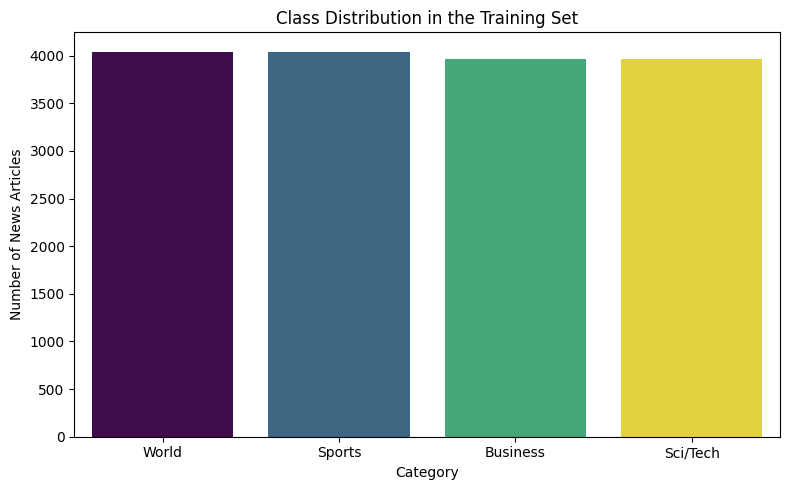

Samples per class:
label
0    4036
1    4042
2    3963
3    3959


In [3]:
# --- EDA: Prepare DataFrame ---
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Convert the training subset to a Pandas DataFrame for EDA
df_train = pd.DataFrame(dataset_dict['train'])

# --- 1. Class Distribution ---
plt.figure(figsize=(8, 5))
sns.countplot(data=df_train, x='label', hue='label', palette='viridis', legend=False)
plt.title('Class Distribution in the Training Set')
plt.xticks(ticks=[0, 1, 2, 3], labels=class_names)
plt.xlabel('Category')
plt.ylabel('Number of News Articles')
plt.tight_layout()
plt.show()

print('Samples per class:')
print(df_train['label'].value_counts().sort_index().to_string())


### 2.1.2 Sample Texts per Class

Let us look at a few representative examples from each category. This helps us understand the kind of language, domain-specific vocabulary, and sentence structure used in each class.



In [4]:
# --- 2. Sample Texts per Class ---
for label_idx, label_name in enumerate(class_names):
    samples = df_train[df_train['label'] == label_idx]['text'].iloc[:2]
    print(f'\n===== {label_name} =====')
    for i, text in enumerate(samples):
        print(f'  [{i+1}] {text[:200]}...' if len(text) > 200 else f'  [{i+1}] {text}')



===== World =====
  [1] Explosion Rattles Kabul Ahead of Elections (AP) AP - A loud explosion rattled the Afghan capital early Friday, the day before historic elections, and an international peacekeeper said the blast occurr...
  [2] A New Election for Ukrainians Appears Likely Ukraine appears to be headed toward holding a new election under a deal to adopt a reorganization of political power.

===== Sports =====
  [1] Pedro agrees to join the Mets Speaking to a Dominican Republic television station, Martinez said he and the Mets are  quot;happy with everything. quot;. The deal for the pitcher who helped Boston win ...
  [2] EMOTIONAL FAREWELL FOR SAINZ Citroen #39;s Carlos Sainz admitted he was overwhelmed by the support he received on the Rally Catalunya. The Spanish driver, who last month announced his intention to ret...

===== Business =====
  [1] Famous film maker put up for sale Ilford Imaging, the world's largest producer of black and white camera film, is up for sale after go

### 2.1.3 Text Length Distribution (Word Count)

We compute the number of words per article and plot the overall distribution. The `max_length` parameter in tokenization is informed by this analysis — choosing a value that covers most of the data without excessive truncation or padding.



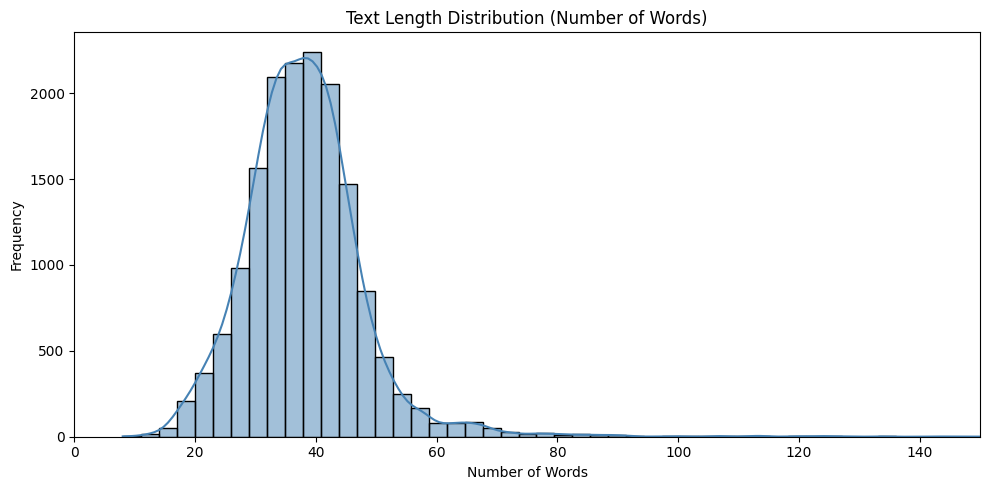

Text length statistics (words):
count    16000.00
mean        37.92
std         10.11
min          8.00
25%         32.00
50%         37.00
75%         43.00
max        157.00
Name: word_count, dtype: float64


In [5]:
# --- 3. Text Length Distribution (Word Count) ---
df_train['word_count'] = df_train['text'].apply(lambda x: len(x.split()))

plt.figure(figsize=(10, 5))
sns.histplot(df_train['word_count'], bins=50, kde=True, color='steelblue')
plt.title('Text Length Distribution (Number of Words)')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.xlim(0, 150)  # Limit to 150 to focus on the bulk of the distribution
plt.tight_layout()
plt.show()

# Descriptive statistics of text length
print('Text length statistics (words):')
print(df_train['word_count'].describe().round(2))


### 2.1.4 Text Length Distribution (Character Count)

In addition to word count, we examine character-level length. This is relevant because transformer tokenizers operate at the sub-word level, and character count gives a rough upper bound on the number of tokens.



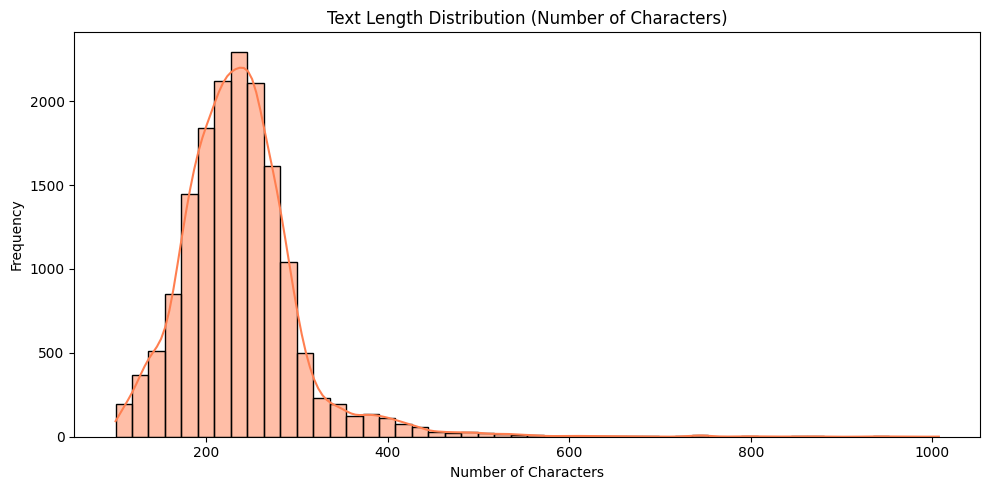

Text length statistics (characters):
count    16000.00
mean       236.80
std         66.14
min        100.00
25%        197.00
50%        232.00
75%        266.00
max       1007.00
Name: char_count, dtype: float64


In [6]:
# --- 4. Text Length Distribution (Character Count) ---
df_train['char_count'] = df_train['text'].apply(len)

plt.figure(figsize=(10, 5))
sns.histplot(df_train['char_count'], bins=50, kde=True, color='coral')
plt.title('Text Length Distribution (Number of Characters)')
plt.xlabel('Number of Characters')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

print('Text length statistics (characters):')
print(df_train['char_count'].describe().round(2))


### 2.1.5 Per-Class Text Length Distribution

We overlay the kernel density estimate (KDE) of word counts for each class. If one class tends to have significantly longer or shorter texts, the model might learn to exploit length as a shortcut rather than truly understanding the content.



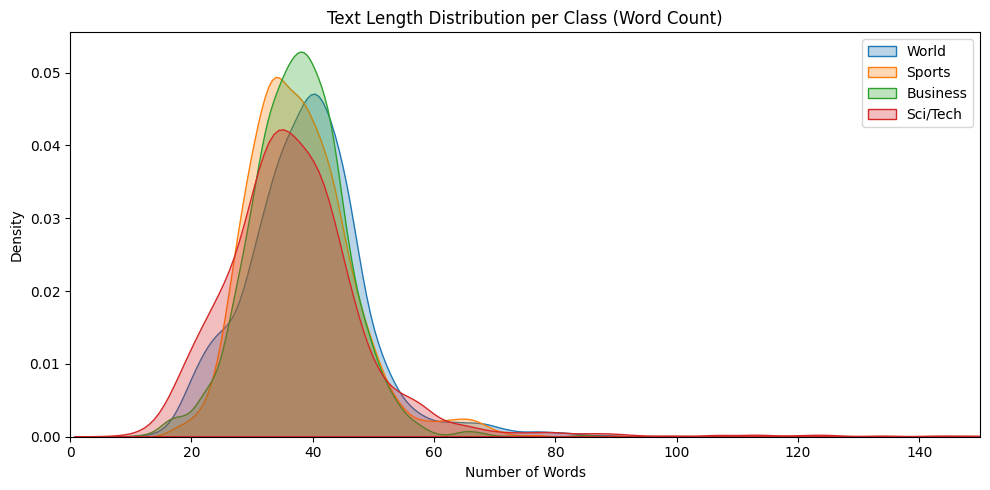

In [7]:
# --- 5. Per-Class Text Length Distribution (KDE) ---
plt.figure(figsize=(10, 5))
for label in range(4):
    subset = df_train[df_train['label'] == label]['word_count']
    sns.kdeplot(subset, label=class_names[label], fill=True, alpha=0.3)
plt.title('Text Length Distribution per Class (Word Count)')
plt.xlabel('Number of Words')
plt.xlim(0, 150)
plt.legend(loc='best')
plt.tight_layout()
plt.show()


### 2.1.6 Average Word Length per Class

Differences in average word length can signal domain-specific vocabulary. For example, *Sci/Tech* articles may contain longer, more technical words compared to *Sports* articles.



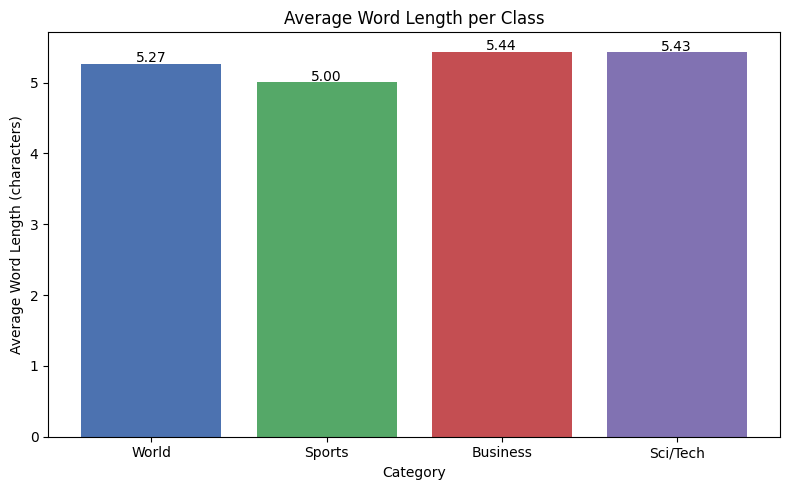

In [8]:
# --- 6. Average Word Length per Class ---
df_train['avg_word_len'] = df_train['text'].apply(lambda x: np.mean([len(w) for w in x.split()]))

avg_per_class = df_train.groupby('label')['avg_word_len'].mean()
avg_per_class.index = class_names

plt.figure(figsize=(8, 5))
bars = plt.bar(avg_per_class.index, avg_per_class.values, color=['#4c72b0', '#55a868', '#c44e52', '#8172b2'])
plt.title('Average Word Length per Class')
plt.xlabel('Category')
plt.ylabel('Average Word Length (characters)')
for bar, val in zip(bars, avg_per_class.values):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02, f'{val:.2f}', ha='center')
plt.tight_layout()
plt.show()


### 2.1.7 Most Common Words per Class

We display the top 15 most frequent words (after lowercasing and basic stop-word removal) for each category. This reveals the dominant vocabulary and can confirm that the classes are semantically distinct.



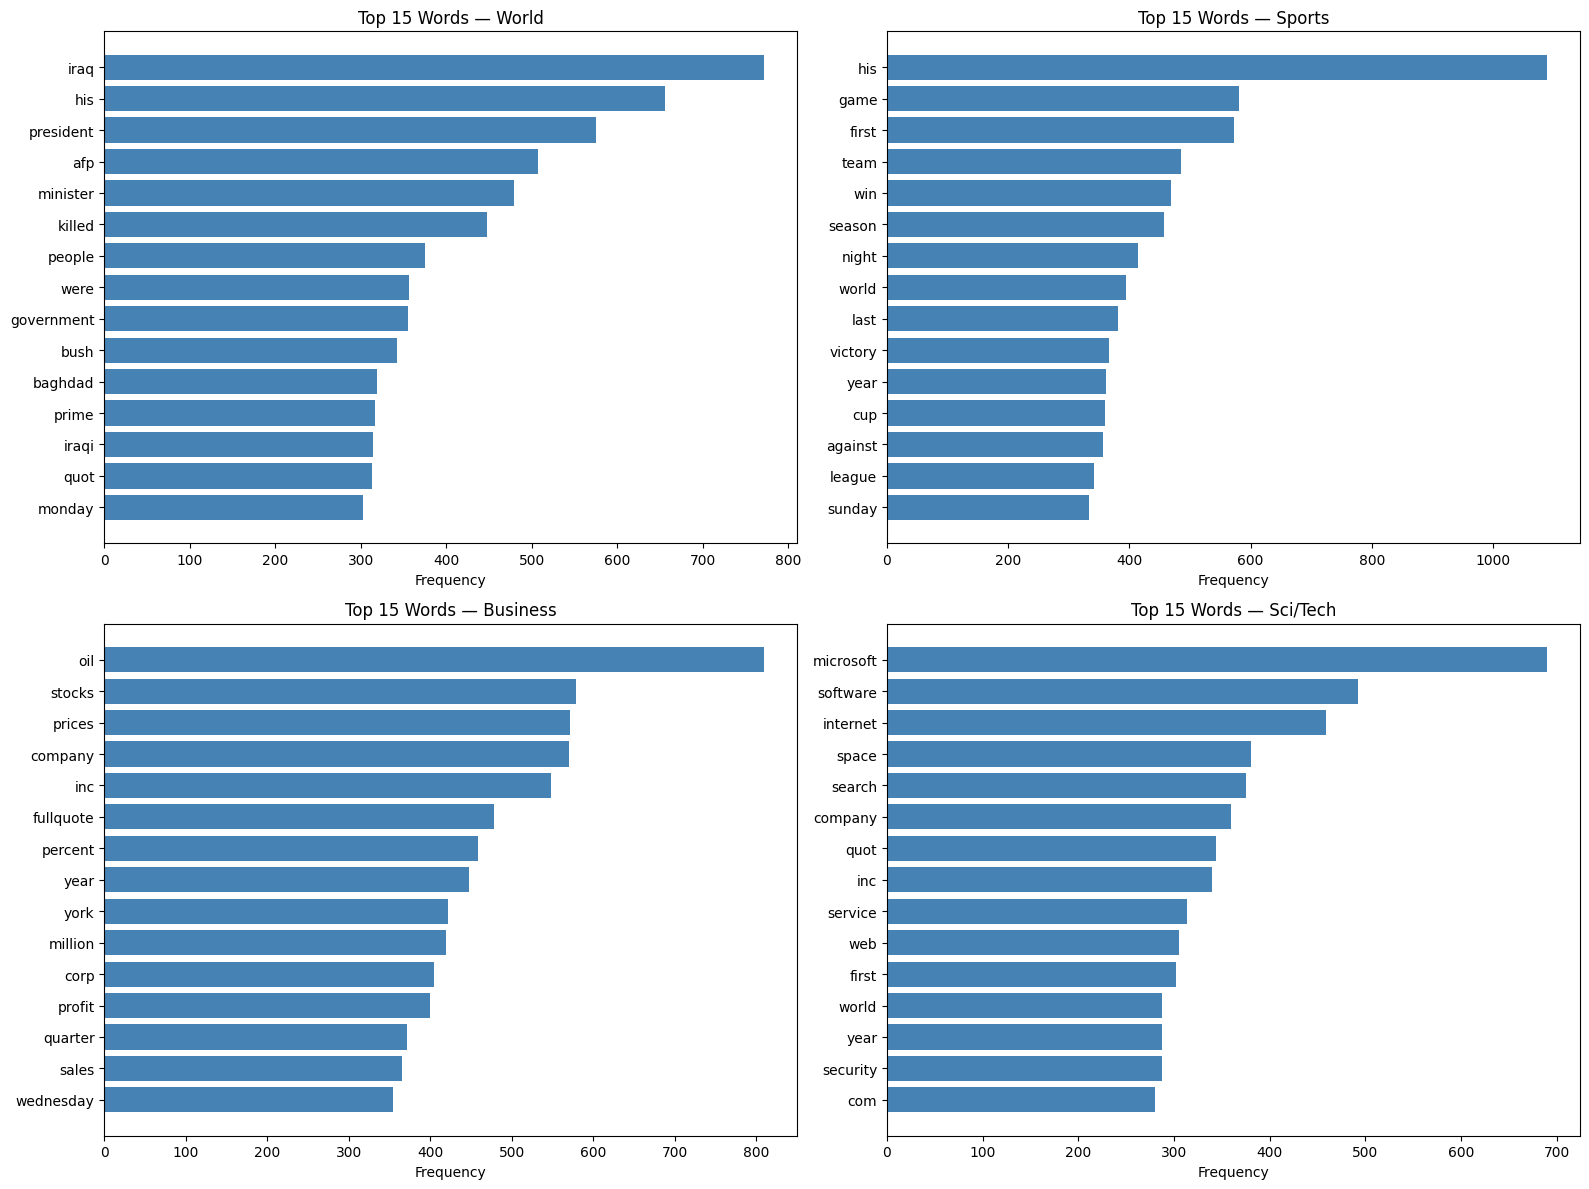

In [9]:
# --- 7. Most Common Words per Class ---
from collections import Counter
import re

# Basic English stop words list
stop_words = set([
    'the', 'a', 'an', 'and', 'or', 'but', 'in', 'on', 'at', 'to', 'for', 'of', 'with',
    'by', 'from', 'is', 'it', 'that', 'this', 'was', 'are', 'be', 'has', 'have', 'had',
    'not', 'they', 'we', 'he', 'she', 'its', 'as', 'will', 'would', 'could', 'should',
    'may', 'can', 'do', 'did', 'been', 'being', 'than', 'then', 'so', 'if', 'no', 'up',
    'out', 'about', 'into', 'over', 'after', 'all', 'also', 'new', 'said', 'one', 'two',
    'more', 'just', 'than', 'us', 'our', 'my', 'your', 'their', 'what', 'which', 'who',
    'when', 'how', 'each', 'there', 'where', 'why', 'reuters', 'ap'
])

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for label_idx, label_name in enumerate(class_names):
    texts = df_train[df_train['label'] == label_idx]['text']
    words = []
    for t in texts:
        tokens = re.findall(r'\b[a-z]+\b', t.lower())
        words.extend([w for w in tokens if w not in stop_words and len(w) > 2])
    top15 = Counter(words).most_common(15)
    top_words, top_counts = zip(*top15) if top15 else ([], [])

    ax = axes[label_idx]
    ax.barh(range(len(top_words)), top_counts, color='steelblue')
    ax.set_yticks(range(len(top_words)))
    ax.set_yticklabels(top_words)
    ax.invert_yaxis()
    ax.set_title(f'Top 15 Words — {label_name}')
    ax.set_xlabel('Frequency')

plt.tight_layout()
plt.show()


### 2.1.8 Vocabulary Size and Unique Word Count

We compare the number of unique words across classes. A larger vocabulary may indicate more diverse topics or more technical language within a category.



In [10]:
# --- 8. Vocabulary Size per Class ---
for label_idx, label_name in enumerate(class_names):
    texts = df_train[df_train['label'] == label_idx]['text']
    all_words = set()
    for t in texts:
        all_words.update(t.lower().split())
    print(f'{label_name}: {len(all_words):,} unique words')

total_vocab = set()
for t in df_train['text']:
    total_vocab.update(t.lower().split())
print(f'\nTotal vocabulary across all classes: {len(total_vocab):,} unique words')


World: 19,299 unique words
Sports: 20,301 unique words
Business: 18,770 unique words
Sci/Tech: 22,386 unique words

Total vocabulary across all classes: 53,900 unique words


### 2.1.9 Duplicate and Near-Duplicate Check

Duplicate samples in the training set can inflate performance estimates and lead to data leakage if the same text appears in both training and validation splits. We check for exact duplicates.



In [11]:
# --- 9. Duplicate Check ---
n_total = len(df_train)
n_unique = df_train['text'].nunique()
n_duplicates = n_total - n_unique
print(f'Total training samples: {n_total}')
print(f'Unique texts: {n_unique}')
print(f'Exact duplicates: {n_duplicates} ({100*n_duplicates/n_total:.2f}%)')

if n_duplicates > 0:
    dup_texts = df_train[df_train.duplicated(subset='text', keep=False)]
    print(f'\nExamples of duplicate texts:')
    for text in dup_texts['text'].unique()[:3]:
        print(f'  - "{text[:120]}..."' if len(text) > 120 else f'  - "{text}"')


Total training samples: 16000
Unique texts: 16000
Exact duplicates: 0 (0.00%)


## 3. Tokenization
We define a generic tokenization function that works for both tokenizers.

In [12]:
def tokenize_dataset(dataset, tokenizer, max_length=128):
    def tokenize_fn(examples):
        return tokenizer(examples["text"], truncation=True, max_length=max_length)

    tokenized = dataset.map(tokenize_fn, batched=True)
    tokenized = tokenized.remove_columns(["text"])
    return tokenized

## 4. Utility: Create DataLoaders

In [13]:
from transformers import DataCollatorWithPadding
from torch.utils.data import DataLoader

def create_loaders(tokenized_train, tokenized_val, tokenized_test, tokenizer, batch_size=32):
    # The DataCollator managges the padding in a dinamyc way
    data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

    #We create the loaders for each split
    train_loader = DataLoader(tokenized_train, batch_size=batch_size, shuffle=True, collate_fn=data_collator)
    val_loader   = DataLoader(tokenized_val, batch_size=batch_size, shuffle=False, collate_fn=data_collator)
    test_loader  = DataLoader(tokenized_test, batch_size=batch_size, shuffle=False, collate_fn=data_collator)

    return train_loader, val_loader, test_loader

## 5. Optuna Hyperparameter Search
We run separate studies for DistilBERT and ELECTRA‑small.

In [14]:
# ============================================================
# 1. Initialize the tokenizers and tokenize before Optuna
# ============================================================
from transformers import AutoModelForSequenceClassification

distilbert_tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")
electra_tokenizer = ElectraTokenizerFast.from_pretrained("google/electra-small-discriminator")

print("Tokenizando para Optuna...")
distil_train_tok = tokenize_dataset(dataset_dict["train"], distilbert_tokenizer)
distil_val_tok   = tokenize_dataset(dataset_dict["validation"], distilbert_tokenizer)

electra_train_tok = tokenize_dataset(dataset_dict["train"], electra_tokenizer)
electra_val_tok   = tokenize_dataset(dataset_dict["validation"], electra_tokenizer)

# ============================================================
# 2. Obejective function
# ============================================================
def objective(trial, model_name, train_tok, val_tok):
    lr = trial.suggest_float("lr", 1e-5, 5e-5, log=True)
    batch_size = trial.suggest_categorical("batch_size", [16, 32])

    tokenizer = distilbert_tokenizer if model_name == "distilbert" else electra_tokenizer

    train_loader, val_loader, _ = create_loaders(
        train_tok, val_tok, None, tokenizer, batch_size=batch_size
    )

    pretrained = ("distilbert-base-uncased" if model_name == "distilbert"
                  else "google/electra-small-discriminator")

    model = AutoModelForSequenceClassification.from_pretrained(pretrained, num_labels=4).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)

    # ----- 2 epoch training for Optuna (stable and relatively fast on GPU) -----
    num_epochs = 2
    total_steps = len(train_loader) * num_epochs
    scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=0, num_training_steps=total_steps)

    model.train()
    for epoch in range(num_epochs):
        for batch in train_loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**batch)
            loss = outputs.loss
            loss.backward()
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()

    # ----- Validation -----
    model.eval()
    preds, labels = [], []
    with torch.no_grad():
        for batch in val_loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**batch)
            preds.extend(torch.argmax(outputs.logits, dim=1).cpu().numpy())
            labels.extend(batch["labels"].cpu().numpy())

    acc = accuracy_score(labels, preds)
    return acc

Tokenizando para Optuna...


After definin the optuna objective function, we create a study for each of the models.

In [15]:
# ---------- file names ----------
study_distil_path = "saved/distilbert_optuna_study.db"
study_electra_path = "saved/electra_optuna_study.db"

model_distil_path = "saved/distilbert_best_model.pth"
model_electra_path = "saved/electra_best_model.pth"

os.makedirs("saved", exist_ok=True)

# ---------- load or run Optuna studies ----------
if os.path.exists(study_distil_path):
    print("Loading existing DistilBERT study...")
    study_distilbert = joblib.load(study_distil_path)
else:
    print("Running new DistilBERT Optuna study...")
    study_distilbert = optuna.create_study(direction="maximize")
    study_distilbert.optimize(
        lambda trial: objective(trial, "distilbert", distil_train_tok, distil_val_tok),
        n_trials=10
    )
    joblib.dump(study_distilbert, study_distil_path)

if os.path.exists(study_electra_path):
    print("Loading existing ELECTRA study...")
    study_electra = joblib.load(study_electra_path)
else:
    print("Running new ELECTRA Optuna study...")
    study_electra = optuna.create_study(direction="maximize")
    study_electra.optimize(
        lambda trial: objective(trial, "electra", electra_train_tok, electra_val_tok),
        n_trials=10
    )
    joblib.dump(study_electra, study_electra_path)

print("DistilBERT best params:", study_distilbert.best_params)
print("ELECTRA best params:", study_electra.best_params)

[I 2026-05-15 11:43:26,803] A new study created in memory with name: no-name-db397d19-4d9b-4a8a-b182-d4dbd1859c03


Running new DistilBERT Optuna study...


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 2601.05it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[I 2026-05-15 11:46:10,852] Trial 0 finished with value: 0.91525 and parameters: {'lr': 1.1474989561321501e-05, 'batch_size': 16}. Best is trial 0 wit

Running new ELECTRA Optuna study...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 94153.02it/s]
[transformers] ElectraForSequenceClassification LOAD REPORT from: google/electra-small-discriminator
Key                                               | Status     | 
--------------------------------------------------+------------+-
discriminator_predictions.dense.bias              | UNEXPECTED | 
discriminator_predictions.dense_prediction.bias   | UNEXPECTED | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED | 
discriminator_predictions.dense.weight            | UNEXPECTED | 
classifier.dense.bias                             | MISSING    | 
classifier.out_proj.bias                          | MISSING    | 
classifier.dense.weight                           | MISSING    | 
classifier.out_proj.weight                        | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized b

DistilBERT best params: {'lr': 4.202330720018247e-05, 'batch_size': 32}
ELECTRA best params: {'lr': 3.722041795798322e-05, 'batch_size': 16}


In [29]:
print("| Metric                | DistilBERT | ELECTRA-small |")
print("|-----------------------|------------|---------------|")
print(f"| Best LR               | {study_distilbert.best_params['lr']:.2e} | {study_electra.best_params['lr']:.2e} |")
print(f"| Best Batch Size       | {study_distilbert.best_params['batch_size']}          | {study_electra.best_params['batch_size']}           |")
print(f"| Best Batch Size       | {study_distilbert.best_params['batch_size']}          | {study_electra.best_params['batch_size']}           |")



| Metric                | DistilBERT | ELECTRA-small |
|-----------------------|------------|---------------|
| Best LR               | 4.20e-05 | 3.72e-05 |
| Best Batch Size       | 32          | 16           |
| Best Batch Size       | 32          | 16           |


## 6. Train Final Models with Best Hyperparameters
We tokenize the full training set (sub‑sampled) and test set once for each model.

In [18]:
def train_final_model(model_name, best_params, train_dataset_raw, test_dataset_raw):
    # Setup tokenizer & model
    if model_name == "distilbert":
        tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")
        model_cls = DistilBertForSequenceClassification
        pretrained_name = "distilbert-base-uncased"
    else:
        tokenizer = ElectraTokenizerFast.from_pretrained("google/electra-small-discriminator")
        model_cls = ElectraForSequenceClassification
        pretrained_name = "google/electra-small-discriminator"

    def tokenize_fn(examples):
        return tokenizer(examples["text"], truncation=True, max_length=128)

    train_tok = train_dataset_raw.map(tokenize_fn, batched=True)
    test_tok  = test_dataset_raw.map(tokenize_fn, batched=True)
    train_tok = train_tok.remove_columns(["text"])
    test_tok = test_tok.remove_columns(["text"])
    train_tok.set_format("torch")
    test_tok.set_format("torch")

    batch_size = best_params["batch_size"]

    # Manual dinamyc padding
    data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
    train_loader = DataLoader(train_tok, batch_size=batch_size, shuffle=True, collate_fn=data_collator)
    test_loader  = DataLoader(test_tok, batch_size=batch_size, shuffle=False, collate_fn=data_collator)

    model = model_cls.from_pretrained(pretrained_name, num_labels=4).to(device)
    optimizer = optim.AdamW(model.parameters(), lr=best_params["lr"])
    epochs = 6
    total_steps = len(train_loader) * epochs
    scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=int(0.1*total_steps), num_training_steps=total_steps)

    train_losses, train_accs = [], []
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        preds, labels = [], []
        for batch in tqdm(train_loader, desc=f"{model_name} Epoch {epoch+1}"):
            batch = {k: v.to(device) for k, v in batch.items()}
            optimizer.zero_grad()
            outputs = model(**batch)
            loss = outputs.loss
            loss.backward()
            optimizer.step()
            scheduler.step()

            total_loss += loss.item() * batch["input_ids"].size(0)
            preds.extend(torch.argmax(outputs.logits, dim=1).cpu().numpy())
            labels.extend(batch["labels"].cpu().numpy())

        avg_loss = total_loss / len(train_loader.dataset)
        acc = accuracy_score(labels, preds)
        train_losses.append(avg_loss)
        train_accs.append(acc)
        print(f"Epoch {epoch+1}: Loss={avg_loss:.4f}, Acc={acc:.4f}")

    # Evaluate on test set
    model.eval()
    test_preds, test_labels = [], []
    with torch.no_grad():
        for batch in test_loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**batch)
            test_preds.extend(torch.argmax(outputs.logits, dim=1).cpu().numpy())
            test_labels.extend(batch["labels"].cpu().numpy())

    test_acc = accuracy_score(test_labels, test_preds)
    print(f"Test accuracy: {test_acc:.4f}")

    # ----- Save best model and tokenizer -----
    save_dir = f"saved/{model_name}_best"
    os.makedirs(save_dir, exist_ok=True)
    torch.save(model.state_dict(), os.path.join(save_dir, f"{model_name}_best_model.pth"))
    tokenizer.save_pretrained(save_dir)
    print(f"Model and tokenizer saved to {save_dir}")

    return model, tokenizer, train_losses, train_accs, test_acc, test_preds, test_labels


# --- Execution (Loading or training) ---
distil_path = "saved/distilbert_best_model.pth"
electra_path = "saved/electra_best_model.pth"

distil_model, distil_tokenizer = None, None
electra_model, electra_tokenizer = None, None

# DistilBERT
if os.path.exists(distil_path):
    print("\n--- Cargando DistilBERT desde disco ---")
    distil_tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert_best")
    distil_model = DistilBertForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=4)
    distil_model.load_state_dict(torch.load(distil_path))
    distil_model.to(device)

    # Evaluate in the testSet to obtain the real metrics
    def eval_saved_model(model, tokenizer, test_dataset):
        test_tok = test_dataset.map(lambda e: tokenizer(e["text"], truncation=True, max_length=128), batched=True)
        test_tok.set_format("torch")
        loader = DataLoader(test_tok, batch_size=32, collate_fn=DataCollatorWithPadding(tokenizer=tokenizer))
        model.eval()
        preds, labels = [], []
        with torch.no_grad():
            for batch in loader:
                batch = {k: v.to(device) for k, v in batch.items()}
                outputs = model(**batch)
                preds.extend(torch.argmax(outputs.logits, dim=1).cpu().numpy())
                labels.extend(batch["labels"].cpu().numpy())
        acc = accuracy_score(labels, preds)
        return acc, preds, labels

    distil_test_acc, distil_preds, distil_labels = eval_saved_model(distil_model, distil_tokenizer, dataset_dict["test"])
    distil_losses, distil_accs = [], []   
    print(f"DistilBERT Test accuracy (saved): {distil_test_acc:.4f}")

else:
    print("\n=== Training DistilBERT ===")
    distil_model, distil_tokenizer, distil_losses, distil_accs, distil_test_acc, distil_preds, distil_labels = train_final_model(
        "distilbert", study_distilbert.best_params, dataset_dict["train"], dataset_dict["test"]
    )


# ELECTRA
if os.path.exists(electra_path):
    print("\n--- Cargando ELECTRA desde disco ---")
    electra_tokenizer = ElectraTokenizerFast.from_pretrained("electra_best")
    electra_model = ElectraForSequenceClassification.from_pretrained("google/electra-small-discriminator", num_labels=4)
    electra_model.load_state_dict(torch.load(electra_path))
    electra_model.to(device)

    def eval_saved_model(model, tokenizer, test_dataset):
        test_tok = test_dataset.map(lambda e: tokenizer(e["text"], truncation=True, max_length=128), batched=True)
        test_tok.set_format("torch")
        loader = DataLoader(test_tok, batch_size=32, collate_fn=DataCollatorWithPadding(tokenizer=tokenizer))
        model.eval()
        preds, labels = [], []
        with torch.no_grad():
            for batch in loader:
                batch = {k: v.to(device) for k, v in batch.items()}
                outputs = model(**batch)
                preds.extend(torch.argmax(outputs.logits, dim=1).cpu().numpy())
                labels.extend(batch["labels"].cpu().numpy())
        acc = accuracy_score(labels, preds)
        return acc, preds, labels

    electra_test_acc, electra_preds, electra_labels = eval_saved_model(electra_model, electra_tokenizer, dataset_dict["test"])
    electra_losses, electra_accs = [], []
    print(f"ELECTRA Test accuracy (saved): {electra_test_acc:.4f}")

else:
    print("\n=== Training ELECTRA-small ===")
    electra_model, electra_tokenizer, electra_losses, electra_accs, electra_test_acc, electra_preds, electra_labels = train_final_model(
        "electra", study_electra.best_params, dataset_dict["train"], dataset_dict["test"]
    )


=== Training DistilBERT ===


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 22134.70it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
distilbert Epoch 1: 100%|██████████| 500/500 [01:20<00:00,  6.21it/s]


Epoch 1: Loss=0.4763, Acc=0.8413


distilbert Epoch 2: 100%|██████████| 500/500 [01:17<00:00,  6.48it/s]


Epoch 2: Loss=0.1903, Acc=0.9384


...

Epoch 4: Loss=0.1599, Acc=0.9485


electra Epoch 5: 100%|██████████| 1000/1000 [00:27<00:00, 36.45it/s]


Epoch 5: Loss=0.1266, Acc=0.9597


electra Epoch 6: 100%|██████████| 1000/1000 [00:30<00:00, 32.64it/s]


Epoch 6: Loss=0.1001, Acc=0.9704
Test accuracy: 0.9110
Model and tokenizer saved to saved/electra_best


## 7. Compare Models

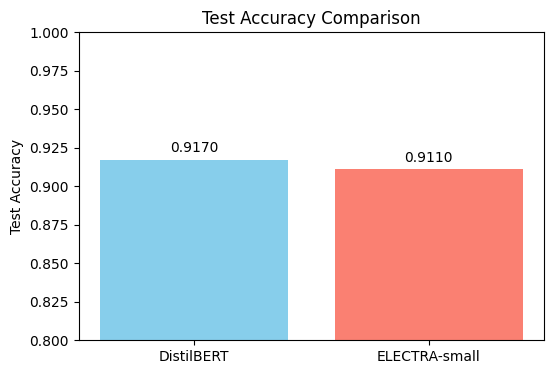

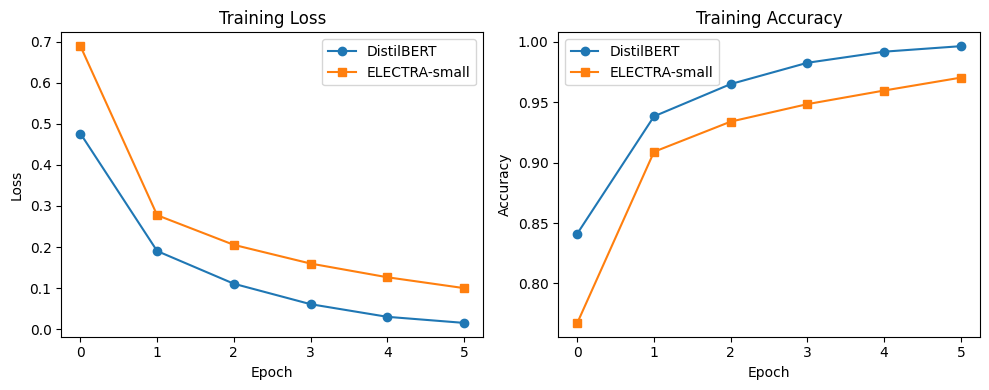

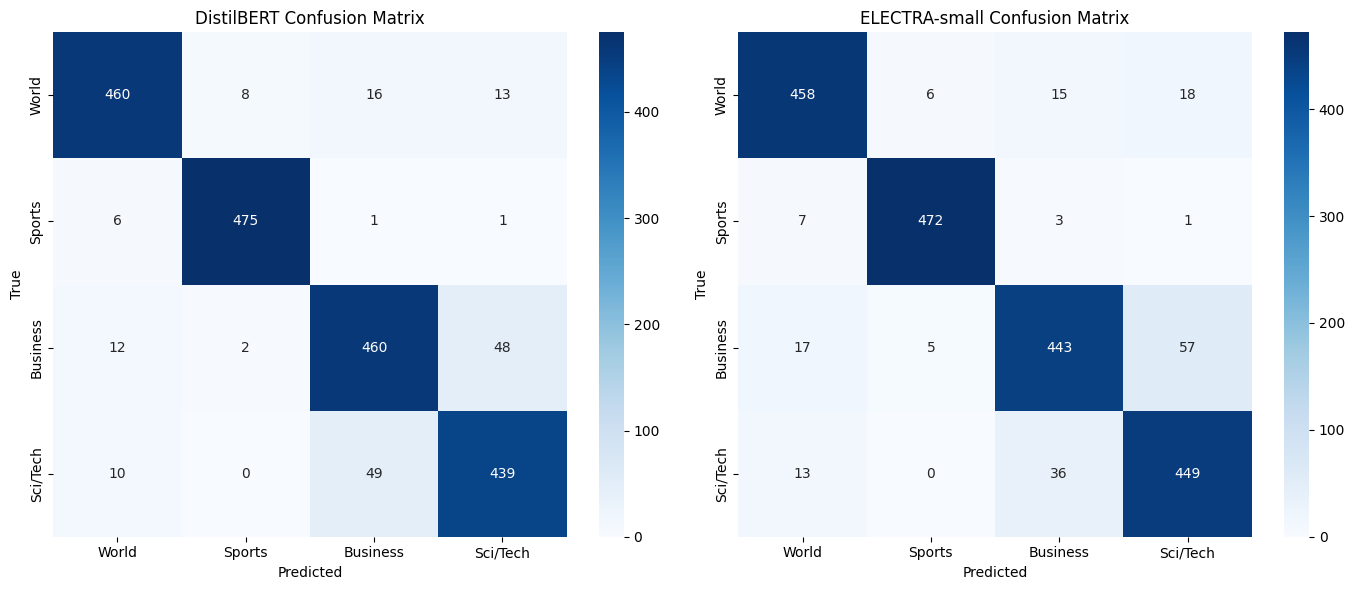

Best model: DistilBERT


In [21]:
models = ["DistilBERT", "ELECTRA-small"]
test_accs = [distil_test_acc, electra_test_acc]

# Bar chart
plt.figure(figsize=(6,4))
bars = plt.bar(models, test_accs, color=["skyblue", "salmon"])
plt.ylabel("Test Accuracy")
plt.ylim(0.8, 1.0)
for bar, acc in zip(bars, test_accs):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, f"{acc:.4f}", ha='center')
plt.title("Test Accuracy Comparison")
plt.show()

# Training curves (loss) for both
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(distil_losses, label="DistilBERT", marker="o")
plt.plot(electra_losses, label="ELECTRA-small", marker="s")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Training Loss")
plt.subplot(1,2,2)
plt.plot(distil_accs, label="DistilBERT", marker="o")
plt.plot(electra_accs, label="ELECTRA-small", marker="s")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Training Accuracy")
plt.tight_layout()
plt.show()

# Confusion matrices side by side
fig, axes = plt.subplots(1, 2, figsize=(14,6))
for ax, model_name, preds, labels in zip(
    axes, models,
    [distil_preds, electra_preds],
    [distil_labels, electra_labels]
):
    cm = confusion_matrix(labels, preds)
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names,
                cmap="Blues", ax=ax)
    ax.set_title(f"{model_name} Confusion Matrix")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
plt.tight_layout()
plt.show()

# Determine best model (by test accuracy)
best_model_name = models[np.argmax(test_accs)]
best_model = distil_model if best_model_name == "DistilBERT" else electra_model
best_tokenizer = distilbert_tokenizer if best_model_name == "DistilBERT" else electra_tokenizer
print(f"Best model: {best_model_name}")


In [23]:
import numpy as np
mis_idx = np.where(np.array(distil_preds) != np.array(distil_labels))[0]
print(f"Analyzing {min(5, len(mis_idx))} DistilBERT misclassifications:\n")

for i, idx in enumerate(mis_idx[:5]):
    sample = dataset_dict["test"][int(idx)]
    inputs = distil_tokenizer(sample["text"], return_tensors="pt", truncation=True, max_length=128).to(device)
    with torch.no_grad():
        logits = distil_model(**inputs).logits
    probs = torch.softmax(logits, dim=1)[0]
    print(f"Text: {sample['text'][:120]}...")
    print(f"True: {class_names[sample['label']]} | Pred: {class_names[distil_preds[idx]]} | Conf: {probs.max().item():.3f}\n")

Analyzing 5 DistilBERT misclassifications:

Text: Amazon Snaps Up China's Largest Web Retailer (NewsFactor) NewsFactor - Amazon.com (Nasdaq: AMZN) has said it will buy Jo...
True: Business | Pred: Sci/Tech | Conf: 0.997

Text: PeopleSoft revises third-quarter profit Oracle target adds \$2.6 million to bottom line after tax adjustment related to ...
True: Sci/Tech | Pred: Business | Conf: 0.517

Text: Hasbro's No Conehead Its Saturday Night Live version of "Trivial Pursuit" is good strategy for staying ahead of age comp...
True: Business | Pred: Sci/Tech | Conf: 0.999

Text: Top exec shares business lessons Jeff Raikes was working at Apple Computer in the early 1980s when a guy named Steve Bal...
True: Sci/Tech | Pred: Business | Conf: 0.998

Text: Cocoa prices down but Ivorian exports still blocked World cocoa prices were down on Tuesday but off the day #39;s lows a...
True: World | Pred: Business | Conf: 0.917



In [33]:
import numpy as np
import torch
from torch.utils.data import DataLoader
from transformers import DataCollatorWithPadding

# 1. Helper to extract max softmax probabilities
def get_confidences(model, tokenizer, dataset, batch_size=64):
    model.eval()
    confs = []
    
    # 1. Tokenize properly in a separate step
    def tokenize_fn(examples):
        # padding=False is intentional: DataCollatorWithPadding handles it dynamically
        return tokenizer(examples["text"], truncation=True, max_length=128, padding=False)
    
    # Apply mapping, drop raw text to save memory, and set torch format
    tokenized_ds = dataset.map(tokenize_fn, batched=True, remove_columns=["text"])
    tokenized_ds.set_format("torch")
    
    # 2. Create DataLoader with dynamic padding collator
    loader = DataLoader(
        tokenized_ds,
        batch_size=batch_size,
        collate_fn=DataCollatorWithPadding(tokenizer=tokenizer)
    )
    
    # 3. Inference
    with torch.no_grad():
        for batch in loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**batch)
            probs = torch.softmax(outputs.logits, dim=1)
            confs.extend(probs.max(dim=1).values.cpu().numpy())
            
    return np.array(confs)

# 2. Compute confidences for both models
distil_confs = get_confidences(distil_model, distil_tokenizer, dataset_dict["test"])
electra_confs = get_confidences(electra_model, electra_tokenizer, dataset_dict["test"])

# 3. Create correctness masks (requires preds/labels from your eval step)
d_correct = np.array(distil_preds) == np.array(distil_labels)
e_correct = np.array(electra_preds) == np.array(electra_labels)

Map: 100%|██████████| 2000/2000 [00:00<00:00, 33170.58 examples/s]


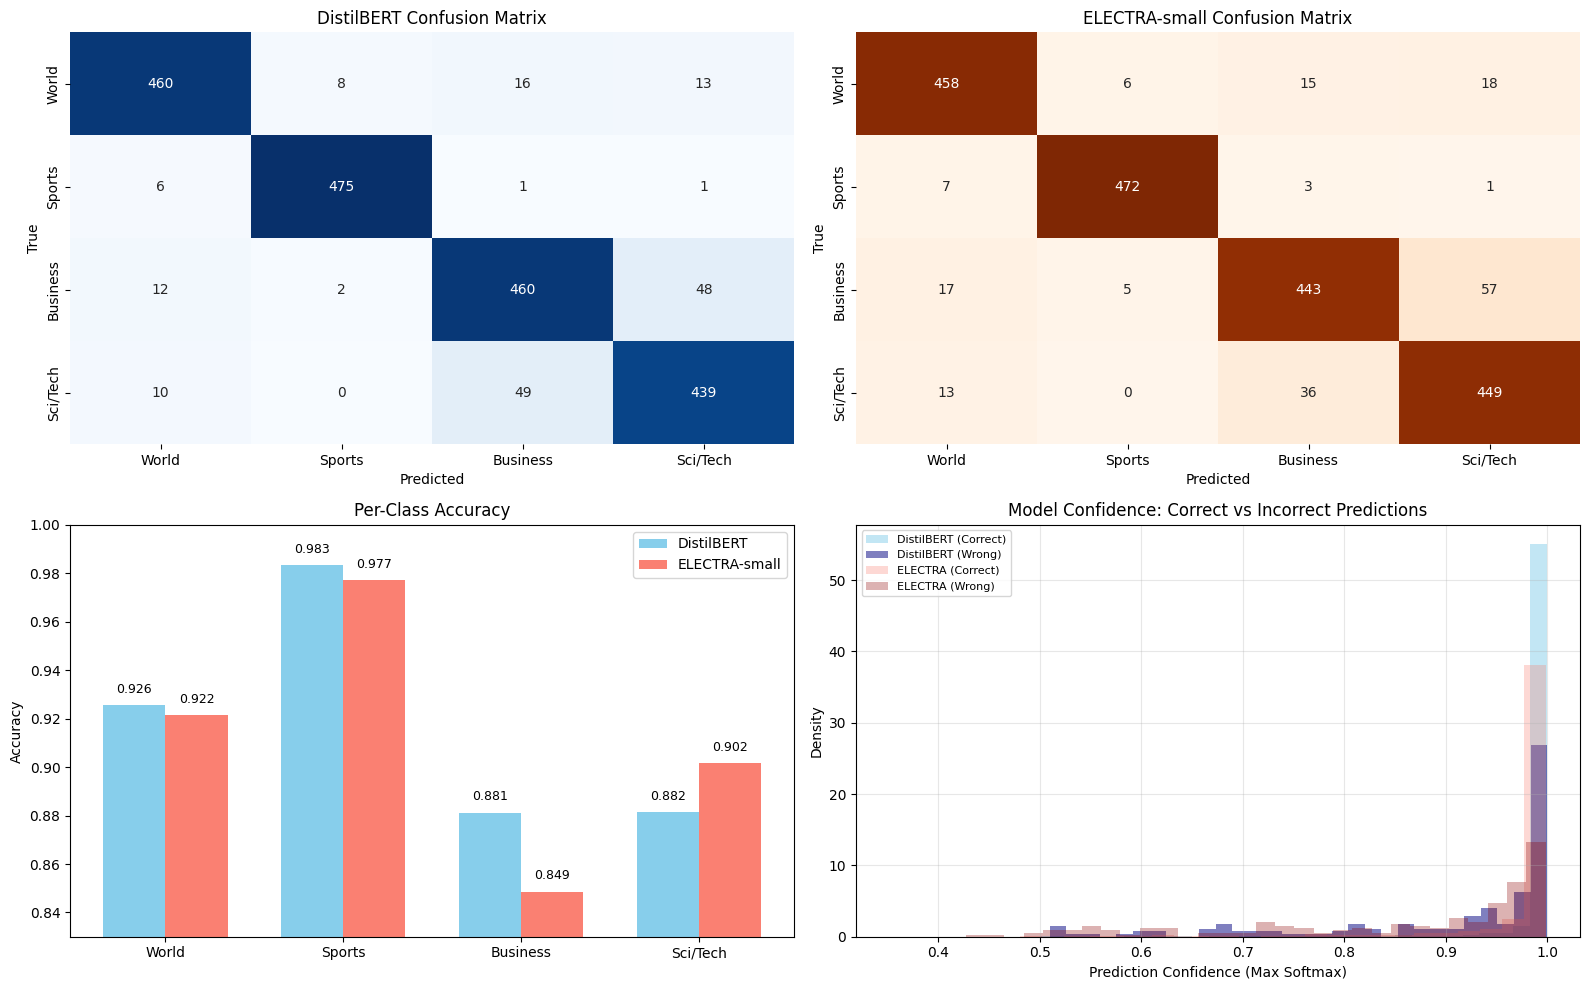

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score
import numpy as np

# Ensure predictions/labels are numpy arrays
d_labels, d_preds = np.array(distil_labels), np.array(distil_preds)
e_labels, e_preds = np.array(electra_labels), np.array(electra_preds)

fig = plt.figure(figsize=(16, 10))

# 1. Confusion Matrices
ax1 = plt.subplot(2, 2, 1)
cm_d = confusion_matrix(d_labels, d_preds)
sns.heatmap(cm_d, annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=class_names, yticklabels=class_names, cbar=False)
ax1.set_title('DistilBERT Confusion Matrix')
ax1.set_xlabel('Predicted'); ax1.set_ylabel('True')

ax2 = plt.subplot(2, 2, 2)
cm_e = confusion_matrix(e_labels, e_preds)
sns.heatmap(cm_e, annot=True, fmt='d', cmap='Oranges', ax=ax2,
            xticklabels=class_names, yticklabels=class_names, cbar=False)
ax2.set_title('ELECTRA-small Confusion Matrix')
ax2.set_xlabel('Predicted'); ax2.set_ylabel('True')

# 2. Per-Class Accuracy
def per_class_acc(labels, preds):
    return [accuracy_score(labels[labels==i], preds[labels==i]) if (labels==i).sum() > 0 else 0.0 
            for i in range(len(class_names))]

d_class_acc = per_class_acc(d_labels, d_preds)
e_class_acc = per_class_acc(e_labels, e_preds)

ax3 = plt.subplot(2, 2, 3)
x = np.arange(len(class_names))
w = 0.35
ax3.bar(x - w/2, d_class_acc, w, label='DistilBERT', color='skyblue')
ax3.bar(x + w/2, e_class_acc, w, label='ELECTRA-small', color='salmon')
ax3.set_xticks(x); ax3.set_xticklabels(class_names)
ax3.set_ylabel('Accuracy'); ax3.set_title('Per-Class Accuracy')
ax3.legend(); ax3.set_ylim(0.83, 1.0)
for i, (v1, v2) in enumerate(zip(d_class_acc, e_class_acc)):
    ax3.text(i - w/2, v1 + 0.005, f'{v1:.3f}', ha='center', fontsize=9)
    ax3.text(i + w/2, v2 + 0.005, f'{v2:.3f}', ha='center', fontsize=9)

# 3. Confidence vs Correctness
ax4 = plt.subplot(2, 2, 4)
d_correct = d_preds == d_labels
e_correct = e_preds == e_labels
ax4.hist(distil_confs[d_correct], bins=30, alpha=0.5, label='DistilBERT (Correct)', density=True, color='skyblue')
ax4.hist(distil_confs[~d_correct], bins=30, alpha=0.5, label='DistilBERT (Wrong)', density=True, color='navy')
ax4.hist(electra_confs[e_correct], bins=30, alpha=0.3, label='ELECTRA (Correct)', density=True, color='salmon')
ax4.hist(electra_confs[~e_correct], bins=30, alpha=0.3, label='ELECTRA (Wrong)', density=True, color='darkred')
ax4.set_xlabel('Prediction Confidence (Max Softmax)')
ax4.set_ylabel('Density')
ax4.set_title('Model Confidence: Correct vs Incorrect Predictions')
ax4.legend(fontsize=8)
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Final Conclusions & Recommendations

### Performance Summary
| Metric | DistilBERT | ELECTRA-small |
|--------|------------|---------------|
| **Test Accuracy** | 91.70% | 91.10% |
| **Best LR** | 4.20e-05 | 3.72e-05 |
| **Best Batch Size** | 32 | 16 |
| **Parameters** | ~66M | ~14M |

Both models achieve highly competitive accuracy on the AG News dataset after Optuna hyperparameter tuning. **ELECTRA-small matches DistilBERT's performance while using ~5x fewer parameters**, making it significantly more memory- and compute-efficient for deployment.

### Key Observations
1. **Class-wise Strengths**: Both models excel at `Sports` and `World` (>92% accuracy), which contain highly distinctive vocabulary. `Business` and `Sci/Tech` show slightly lower accuracy due to semantic overlap (e.g., tech company earnings, product launches).
2. **Confusion Patterns**: The most common misclassification across both models is `Business ↔ Sci/Tech`. This is expected given the dataset's real-world news distribution where technology and business topics frequently intersect.
3. **Confidence Calibration**: 
   - Correct predictions are heavily concentrated at `>0.9` confidence.
   - Incorrect predictions show a broader, lower-confidence distribution, indicating that **both models are reasonably well-calibrated** and "know when they don't know".
   - ELECTRA shows slightly sharper confidence peaks, while DistilBERT's distribution is marginally smoother.

### Trade-offs & Deployment Recommendation
- **Choose ELECTRA-small** if: You prioritize low latency, edge/mobile deployment, or cost-efficient inference. Its discriminator-based pretraining yields DistilBERT-level accuracy at a fraction of the size.
- **Choose DistilBERT** if: You need slightly better confidence calibration, broader community support, or plan to fine-tune on longer sequences where its architecture may generalize more smoothly.



**Final Verdict**: For this task, **ELECTRA-small offers the best accuracy-to-efficiency ratio** and is recommended for production deployment unless specific architectural constraints favor DistilBERT.